In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("personality_datasert.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df.count()

,0
Time_spent_Alone,2900
Stage_fear,2900
Social_event_attendance,2900
Going_outside,2900
Drained_after_socializing,2900
Friends_circle_size,2900
Post_frequency,2900
Personality,2900


In [6]:
Time_spent_Alone = [df['Friends_circle_size'] == 'Time_spent_Alone']
Time_spent_Alone

[0       False
 1       False
 2       False
 3       False
 4       False
         ...  
 2895    False
 2896    False
 2897    False
 2898    False
 2899    False
 Name: Friends_circle_size, Length: 2900, dtype: bool]

In [8]:
df.isnull().sum()

,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


In [9]:
df.isnull()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2895,False,False,False,False,False,False,False,False
2896,False,False,False,False,False,False,False,False
2897,False,False,False,False,False,False,False,False
2898,False,False,False,False,False,False,False,False


In [11]:
df.shape

(2900, 8)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(2498, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2498 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2498 non-null   float64
 1   Stage_fear                 2498 non-null   object 
 2   Social_event_attendance    2498 non-null   float64
 3   Going_outside              2498 non-null   float64
 4   Drained_after_socializing  2498 non-null   object 
 5   Friends_circle_size        2498 non-null   float64
 6   Post_frequency             2498 non-null   float64
 7   Personality                2498 non-null   object 
dtypes: float64(5), object(3)
memory usage: 175.6+ KB


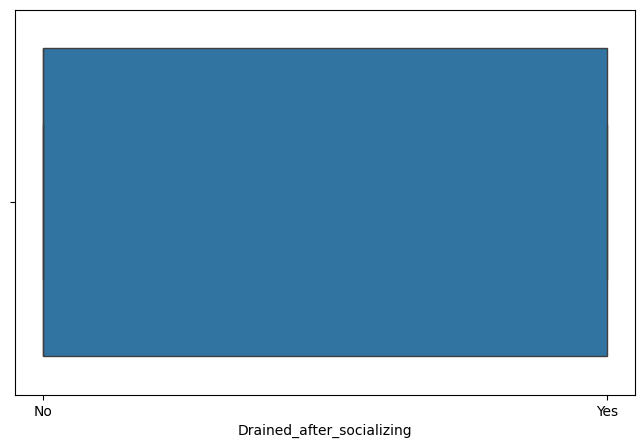

In [18]:
# Set the plot figure
plt.figure(figsize=(8,5))
# Boxplot
sns.boxplot(x=df['Drained_after_socializing'])
plt.xlabel("Drained_after_socializing")
plt.show()

In [19]:
def count_outliers(dataframe, column_name):
    column_data = dataframe[column_name]

    q1 = column_data.quantile(0.25)
    q3 = column_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    outliers = column_data[(column_data<lower_bound) | (column_data>upper_bound)]
    return len(outliers)

In [21]:
count_outliers(df,'Time_spent_Alone')

0

In [26]:
attributes = ['Post_frequency', 'Friends_circle_size' , 'Social_event_attendance' , 'Time_spent_Alone']

for attribute in attributes:
    count = count_outliers(df, attribute)
    print(attribute)
    print('Number of outliers:',count,'out of',len(df[attribute]))

Post_frequency
Number of outliers: 0 out of 2498
Friends_circle_size
Number of outliers: 0 out of 2498
Social_event_attendance
Number of outliers: 0 out of 2498
Time_spent_Alone
Number of outliers: 0 out of 2498


In [27]:
def remove_outliers(dataFrame, column_name):
    column_data = dataFrame[column_name]
    q1 = column_data.quantile(0.25)
    q3 = column_data.quantile(0.75)
    iqr = q3-q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered_df = dataFrame[(column_data >= lower_bound) & (column_data <= upper_bound)]
    return filtered_df

In [29]:
outlier_removed_df = remove_outliers(df,'Post_frequency')
print("Original df:",df.shape)
print("Df shape after removing outlier:",outlier_removed_df.shape)

Original df: (2498, 8)
Df shape after removing outlier: (2498, 8)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2498 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2498 non-null   float64
 1   Stage_fear                 2498 non-null   object 
 2   Social_event_attendance    2498 non-null   float64
 3   Going_outside              2498 non-null   float64
 4   Drained_after_socializing  2498 non-null   object 
 5   Friends_circle_size        2498 non-null   float64
 6   Post_frequency             2498 non-null   float64
 7   Personality                2498 non-null   object 
dtypes: float64(5), object(3)
memory usage: 175.6+ KB


In [31]:
df['Stage_fear'].unique()

array(['No', 'Yes'], dtype=object)

In [32]:
df['Drained_after_socializing'].unique()

array(['No', 'Yes'], dtype=object)

In [33]:
df['Personality'].unique()

array(['Extrovert', 'Introvert'], dtype=object)

In [35]:
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of OrdinalEncoder
encoder = OrdinalEncoder(categories=[list(df['Personality'].unique()), list(df['Stage_fear'].unique()), list(df['Drained_after_socializing'].unique())])

In [36]:
# Select only the categorical columns for encoding
categorical_columns = ['Personality', 'Stage_fear', 'Drained_after_socializing']
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

In [37]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,0.0
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,1.0
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,1.0
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,0.0
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,0.0


In [38]:
print(df['Personality'].value_counts())

Personality
0.0    1403
1.0    1095
Name: count, dtype: int64


In [39]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler instance
scaler = StandardScaler()

# Separate the target column
target_column = df['Personality']

# Normalize all columns except the target column
df[df.columns.difference(['Personality'])] = scaler.fit_transform(df[df.columns.difference(['Personality'])])

# Assign the target column back to the DataFrame
df['Personality'] = target_column

<Axes: >

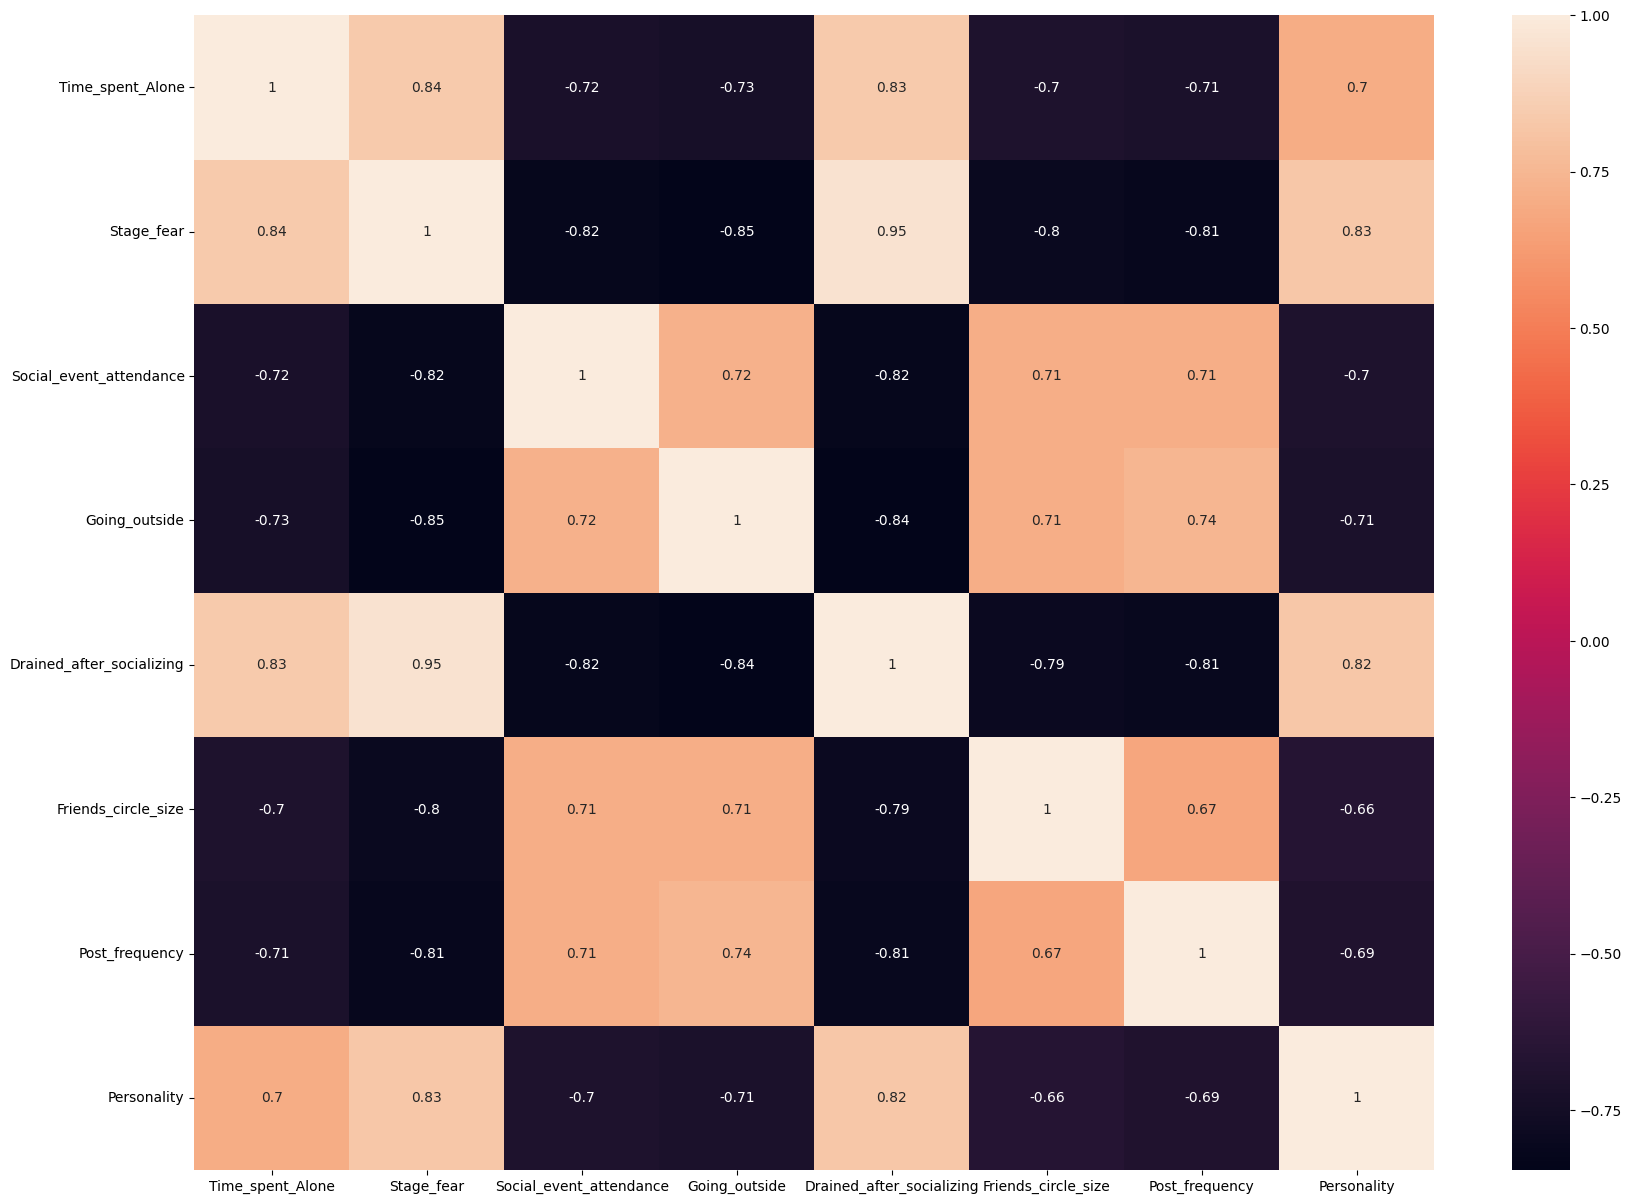

In [40]:
plt.subplots(figsize=(20,15))
sns.heatmap(df.corr(), annot=True)

In [41]:
from sklearn.model_selection import train_test_split

y = df['Personality']
x = df.drop(columns='Personality')

In [42]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [44]:
corr_features = correlation(x_temp, 0.85)
len(set(corr_features))

1

In [45]:
corr_features

{'Drained_after_socializing'}

In [46]:
x_train.drop(corr_features,axis=1)
x_temp.drop(corr_features,axis=1)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
2626,-0.068154,1.135624,-0.765857,-1.439329,-1.075991,-0.623023
2096,0.519054,1.135624,-0.417877,-0.537763,-0.371213,-0.966233
961,0.812658,1.135624,-0.417877,-0.537763,-1.545842,-1.309442
2555,1.399866,1.135624,-0.765857,-0.537763,-1.310916,-1.309442
1412,-0.655362,-0.880573,0.974042,0.363802,1.038341,1.093026
...,...,...,...,...,...,...
2321,-0.361758,-0.880573,0.278082,1.265368,1.978045,0.406606
2090,-1.242570,-0.880573,0.974042,1.265368,0.333564,0.406606
2093,1.106262,1.135624,-1.461817,-0.988546,-0.606139,-0.623023
1251,0.519054,1.135624,-1.461817,-1.439329,-1.310916,-0.623023


In [47]:
df = x_train.drop(corr_features,axis=1)
x_temp.drop(corr_features,axis=1)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
2626,-0.068154,1.135624,-0.765857,-1.439329,-1.075991,-0.623023
2096,0.519054,1.135624,-0.417877,-0.537763,-0.371213,-0.966233
961,0.812658,1.135624,-0.417877,-0.537763,-1.545842,-1.309442
2555,1.399866,1.135624,-0.765857,-0.537763,-1.310916,-1.309442
1412,-0.655362,-0.880573,0.974042,0.363802,1.038341,1.093026
...,...,...,...,...,...,...
2321,-0.361758,-0.880573,0.278082,1.265368,1.978045,0.406606
2090,-1.242570,-0.880573,0.974042,1.265368,0.333564,0.406606
2093,1.106262,1.135624,-1.461817,-0.988546,-0.606139,-0.623023
1251,0.519054,1.135624,-1.461817,-1.439329,-1.310916,-0.623023


In [48]:
df = x_train.drop(corr_features,axis=1)
x_temp.drop(corr_features,axis=1)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
2626,-0.068154,1.135624,-0.765857,-1.439329,-1.075991,-0.623023
2096,0.519054,1.135624,-0.417877,-0.537763,-0.371213,-0.966233
961,0.812658,1.135624,-0.417877,-0.537763,-1.545842,-1.309442
2555,1.399866,1.135624,-0.765857,-0.537763,-1.310916,-1.309442
1412,-0.655362,-0.880573,0.974042,0.363802,1.038341,1.093026
...,...,...,...,...,...,...
2321,-0.361758,-0.880573,0.278082,1.265368,1.978045,0.406606
2090,-1.242570,-0.880573,0.974042,1.265368,0.333564,0.406606
2093,1.106262,1.135624,-1.461817,-0.988546,-0.606139,-0.623023
1251,0.519054,1.135624,-1.461817,-1.439329,-1.310916,-0.623023


In [49]:
df.shape

(1998, 6)

<Axes: >

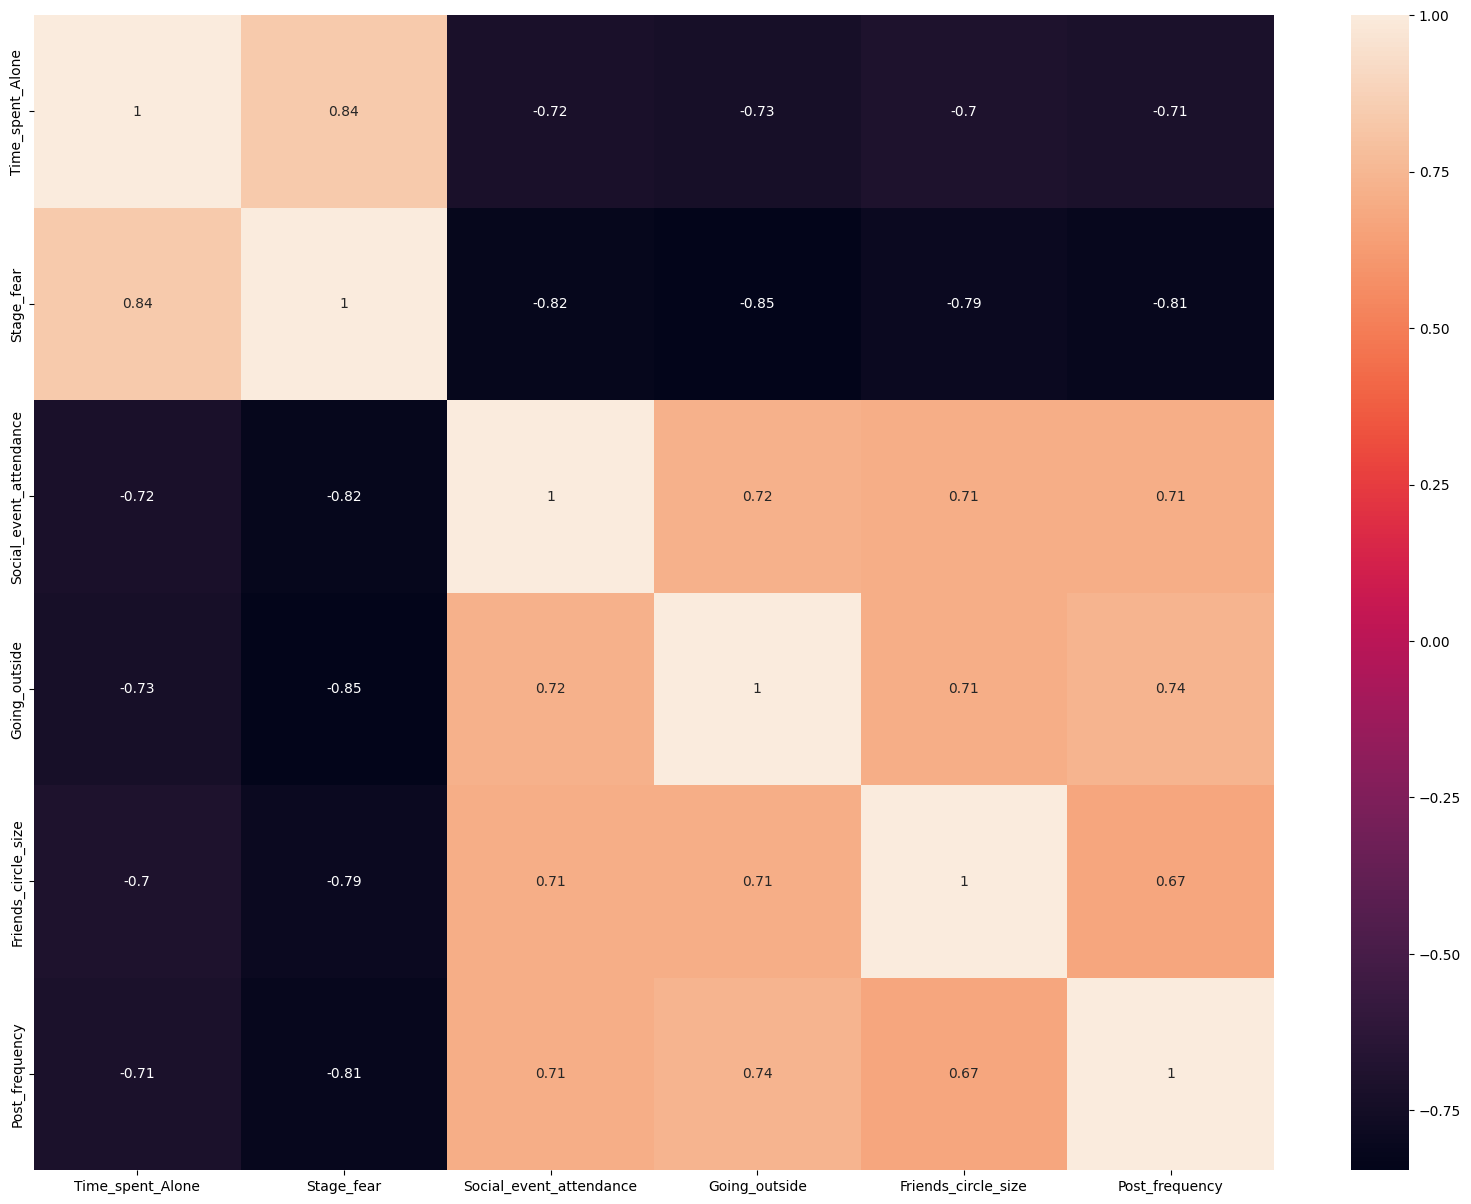

In [50]:
plt.subplots(figsize=(20,15))
sns.heatmap(df.corr(), annot=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 110 to 913
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Time_spent_Alone         1998 non-null   float64
 1   Stage_fear               1998 non-null   float64
 2   Social_event_attendance  1998 non-null   float64
 3   Going_outside            1998 non-null   float64
 4   Friends_circle_size      1998 non-null   float64
 5   Post_frequency           1998 non-null   float64
dtypes: float64(6)
memory usage: 109.3 KB


In [52]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_temp)

Accuracy: 0.82
Precision: 0.7990867579908676
Recall: 0.7918552036199095
F1 Score: 0.7954545454545454
AUC-ROC: 0.8246971245073713


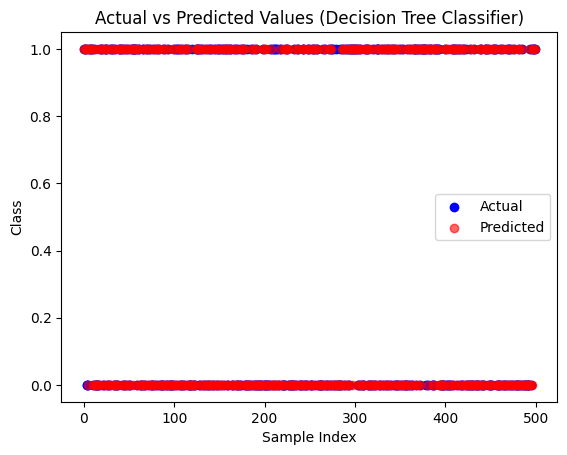

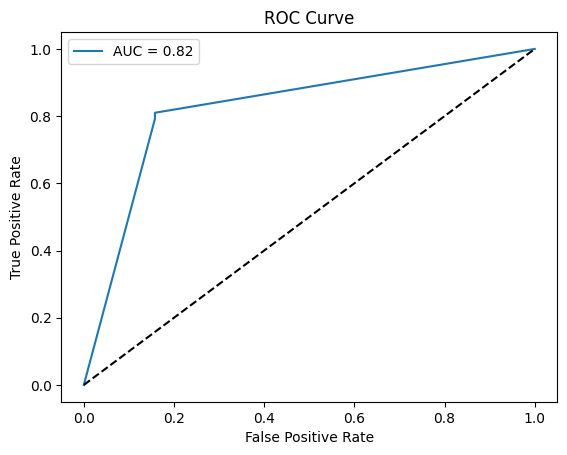

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


# Train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

# Predict on test/temporary set
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]  # For AUC-ROC

# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Confusion Matrix:
[[235  44]
 [ 46 175]]


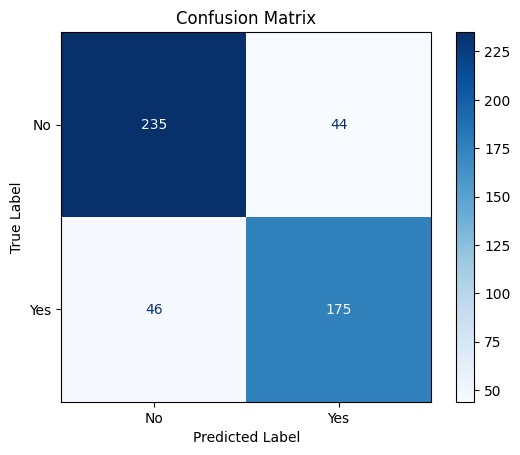

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_temp, y_pred)

# Print the confusion matrix values
print("Confusion Matrix:")
print(cm)

# Display the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Accuracy: 0.82
Precision: 0.7990867579908676
Recall: 0.7918552036199095
F1 Score: 0.7954545454545454
AUC-ROC: 0.8246971245073713


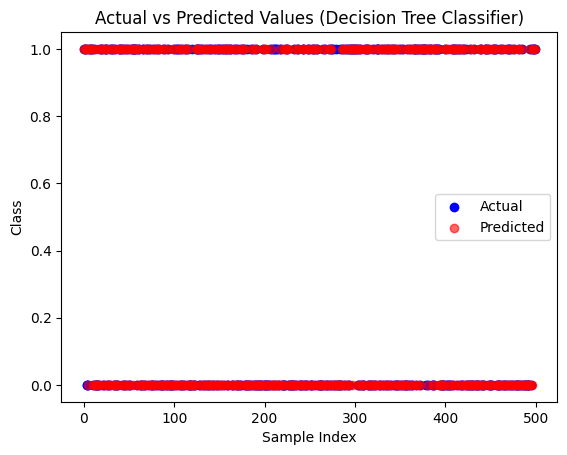

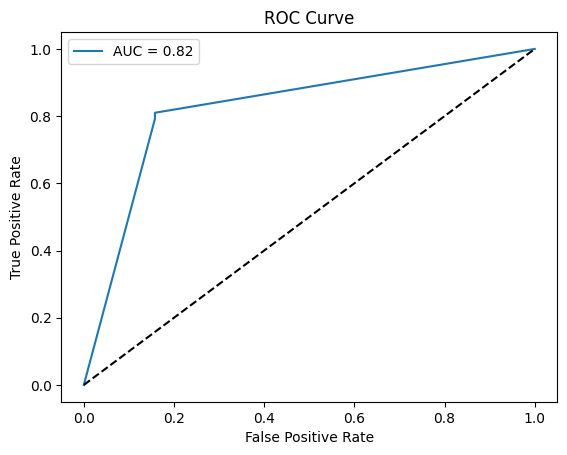

In [57]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]
# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Accuracy: 0.88
Precision: 0.8577777777777778
Recall: 0.8733031674208145
F1 Score: 0.8654708520179372
AUC-ROC: 0.9327592079015229


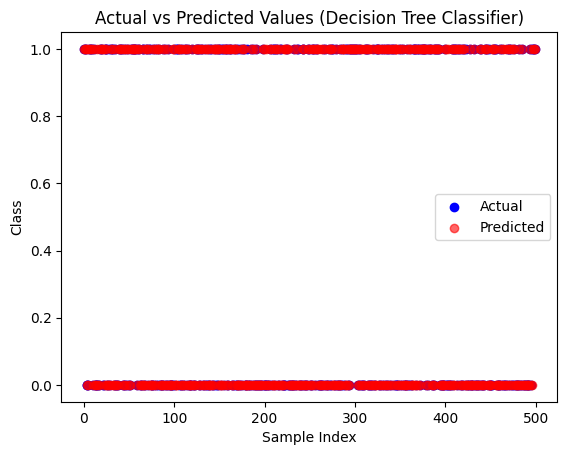

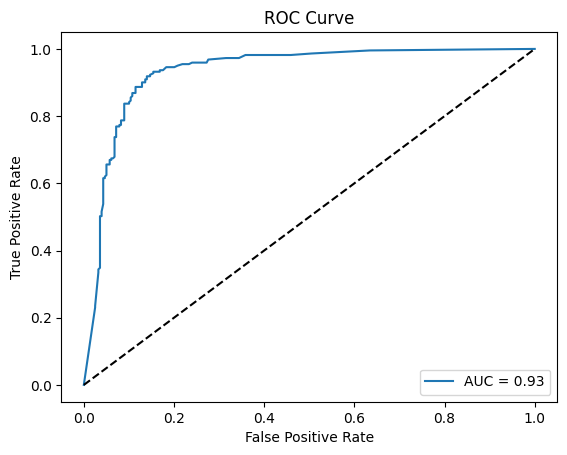

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]
# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Accuracy: 0.908
Precision: 0.8787878787878788
Recall: 0.918552036199095
F1 Score: 0.8982300884955752
AUC-ROC: 0.9374138406396472


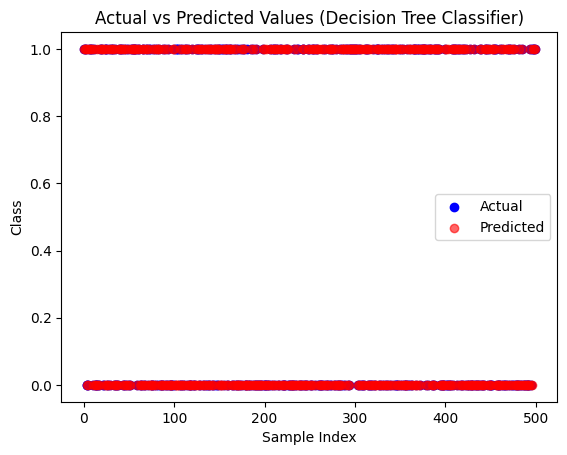

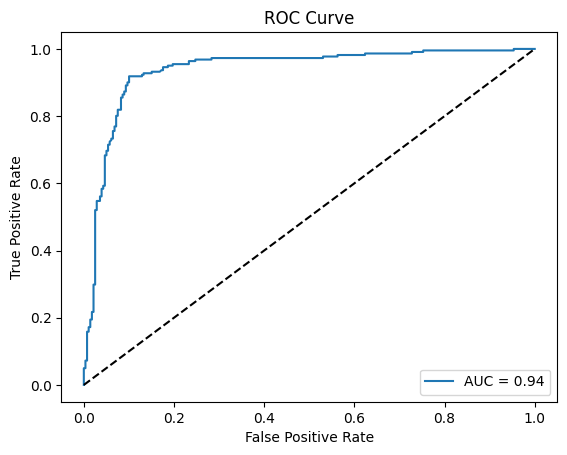

In [63]:
from sklearn.svm import SVC

model = SVC(probability=True, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]
# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Accuracy: 0.908
Precision: 0.8787878787878788
Recall: 0.918552036199095
F1 Score: 0.8982300884955752
AUC-ROC: 0.8782172918795309


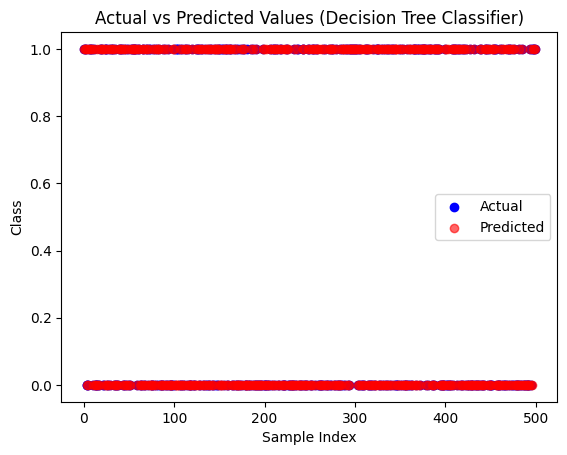

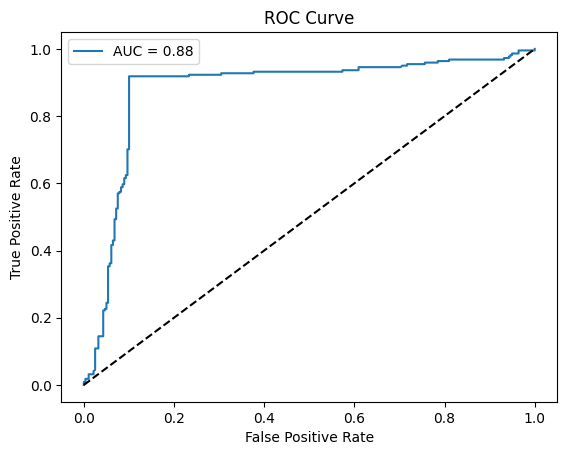

In [64]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]
# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Accuracy: 0.904
Precision: 0.8744588744588745
Recall: 0.9140271493212669
F1 Score: 0.8938053097345132
AUC-ROC: 0.9320293874373571


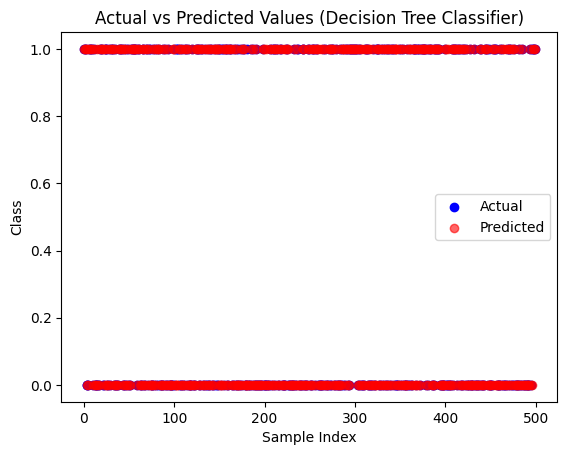

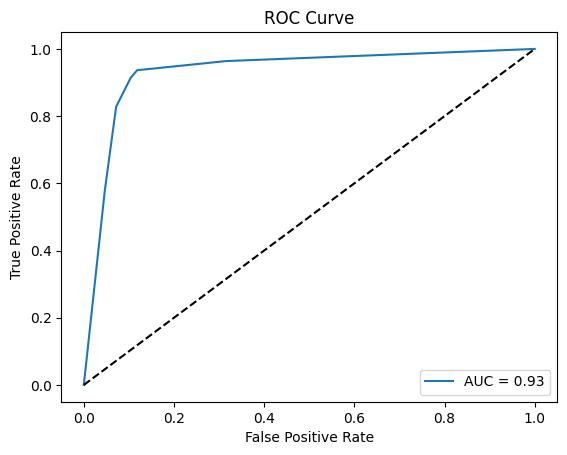

In [65]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)
y_pred = model.predict(x_temp)
y_pred_proba = model.predict_proba(x_temp)[:, 1]
# Calculate Accuracy
accuracy = accuracy_score(y_temp, y_pred)

# Calculate Precision
precision = precision_score(y_temp, y_pred)

# Calculate Recall
recall = recall_score(y_temp, y_pred)

# Calculate F1 Score
f1 = f1_score(y_temp, y_pred)

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_temp, y_pred_proba)

# Print Metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot Actual vs Predicted (Optional Visualization for classification)
plt.scatter(range(len(y_temp)), y_temp, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values (Decision Tree Classifier)")
plt.legend()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_temp, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
